In [9]:
import numpy as np
import matplotlib.pyplot as plt

## Chapter 03 — Linear Algebra I: Vectors

A **vector** is the basic object of linear algebra, and linear algebra is the
language machine learning is written in. A data point (the pixels of an image,
the features of a house, the word counts of a document) is a vector. A model's
weights are a vector. Comparing, combining, and measuring vectors is most of
what an ML algorithm does.

In this notebook we treat a vector two ways at once:

- **algebraically** — a list of numbers, stored as a 1D NumPy array;
- **geometrically** — an arrow in space, which lets us *see* what the algebra
  means.

____
### 1. A vector is a 1D NumPy array

On paper we write a vector as a column (or row) of numbers:

$$\mathbf{a} = \begin{bmatrix} 3 \\ 4 \end{bmatrix}, \qquad
\mathbf{b} = (1,\, 2,\, 2).$$

In NumPy a vector is just a **1D array**. The number of entries is its
*dimension*.

___
**a is a 1D NumPy array representing a 2D vector.**

* **1D NumPy array** → it has one axis (a.ndim == 1)
* **2D vector** → it has two components/entries (3 and 4)

In [10]:
a = np.array([3, 4])         # a vector in 2D
b = np.array([1, 2, 2])      # a vector in 3D

print("a       =", a)
print("b       =", b)
print("a shape =", a.shape)  # (2,)  -> one axis, two entries
print("a dim   =", a.ndim)   # 1     -> it is one-dimensional
print("len(b)  =", len(b))   # 3     -> b lives in 3D

a       = [3 4]
b       = [1 2 2]
a shape = (2,)
a dim   = 1
len(b)  = 3


____
### 2. Addition and scalar multiplication

These are the *only two* operations that define a vector space, and NumPy does
them entry by entry.

**Addition** lines up corresponding entries:
$$\mathbf{a} + \mathbf{b}
= \begin{bmatrix} a_1 + b_1 \\ a_2 + b_2 \end{bmatrix}.$$

**Scalar multiplication** stretches (or flips) a vector:
$$s\,\mathbf{a} = \begin{bmatrix} s\,a_1 \\ s\,a_2 \end{bmatrix}.$$

In [11]:
a = np.array([2.0, 1.0])
b = np.array([1.0, 3.0])

print("a + b      =", a + b)     # [3., 4.]  -> entrywise sum
print("a - b      =", a - b)     # [1., -2.]
print("2 * a      =", 2 * a)     # [4., 2.]  -> scaled by 2
print("-1 * b     =", -1 * b)    # [-1., -3.] -> flipped direction
print("0.5*a + 3*b =", 0.5 * a + 3 * b)  # a 'linear combination'

a + b      = [3. 4.]
a - b      = [ 1. -2.]
2 * a      = [4. 2.]
-1 * b     = [-1. -3.]
0.5*a + 3*b = [4.  9.5]


____
### Seeing the geometry: the parallelogram rule

An arrow from the origin to the point $(a_1, a_2)$ *is* the vector
$\mathbf{a}$. Adding $\mathbf{b}$ means placing $\mathbf{b}$'s tail at
$\mathbf{a}$'s head. We draw arrows with Matplotlib's `quiver`.

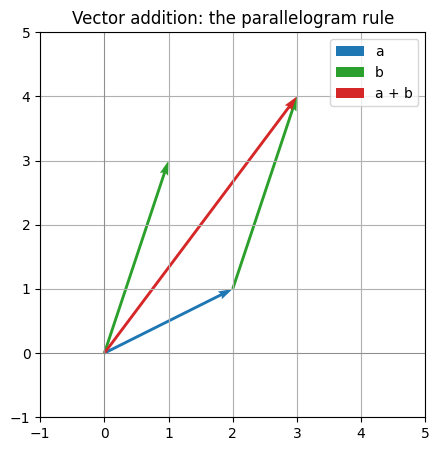

In [14]:
a = np.array([2.0, 1.0])
b = np.array([1.0, 3.0])
s = a + b

# Helper: draw one arrow from a starting point 'tail' along 'vec'.
def arrow(tail, vec, color, label):
    plt.quiver(tail[0], tail[1], vec[0], vec[1],
               angles="xy", scale_units="xy", scale=1,
               color=color, label=label)

plt.figure(figsize=(5, 5))
arrow([0, 0], a, "tab:blue", "a")
arrow([0, 0], b, "tab:green", "b")
arrow(a, b, "tab:green", None)  # b shifted to a's head (dashed idea)
arrow([0, 0], s, "tab:red", "a + b")    # the diagonal is the sum

plt.xlim(-1, 5); plt.ylim(-1, 5)
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)

plt.title("Vector addition: the parallelogram rule")
plt.grid(True)
plt.gca().set_aspect("equal")   # get current axes; make the x/y scales equal
plt.legend(); plt.show()